# SVM 
A Support Vector Machine (SVM) is a supervised machine learning algorithm that finds the optimal hyperplane that best separates data points of different classes by maximizing the margin between them.

Key concepts: <br>
Hyperplane: The decision boundary that separates different classes. <br>
Support Vectors: The data points closest to the hyperplane. These points determine the position of the hyperplane. <br>
Margin: The distance between the hyperplane and the nearest support vectors. SVM aims to maximize this margin for better generalization.   <br>

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns; sns.set()

Working with Perfectly Linear Dataset

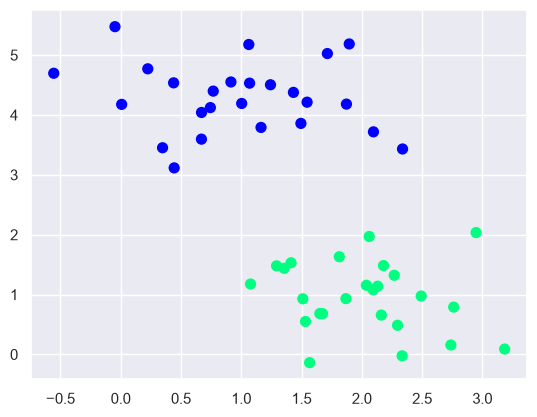

In [2]:
from sklearn.datasets._samples_generator import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

import SVM --> Classifier lib to implement on dataset 

In [3]:
from sklearn.svm import SVC 
model = SVC(kernel='linear', C=1)
model.fit(X,y)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


After training the data: - <br>
- model.coef_ gives the learned w.
- model.intercept_ gives b.
- model.support_vectors_ gives the support vectors.

In [9]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""

    if ax is None:
        ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    X, Y = np.meshgrid(x, y)

    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # Plot decision boundary and margins
    ax.contour(
        X, Y, P,
        colors='k',
        levels=[-1, 0, 1],
        alpha=0.5,
        linestyles=['--', '-', '--']
    )

    # Plot support vectors
    if plot_support:
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidths=1,
            facecolors='none',
            edgecolors='k'
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

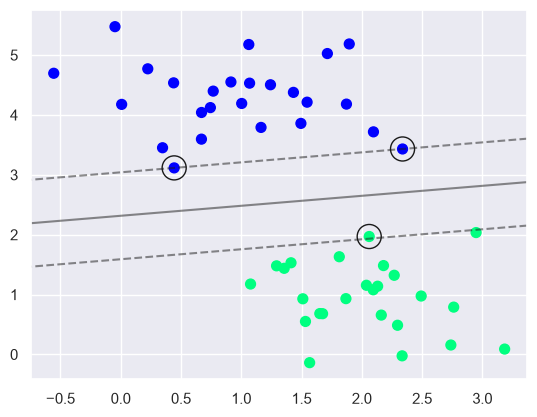

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model)
plt.show()

The importance of Support Vectors


In [14]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(
        n_samples=200,
        centers=2,
        random_state=0,
        cluster_std=0.60
    )

    X = X[:N]
    y = y[:N]

    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    if ax is None:
        ax = plt.gca()

    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)

    plot_svc_decision_function(model, ax)

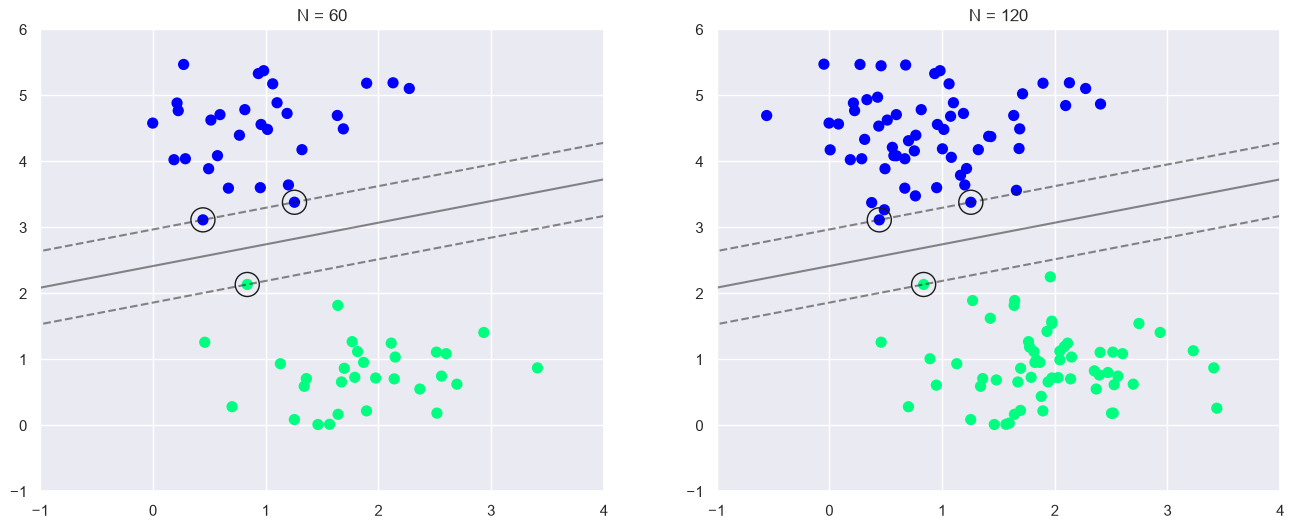

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title(f"N = {N}")

plt.show()

Working with almost linearly separable dataset

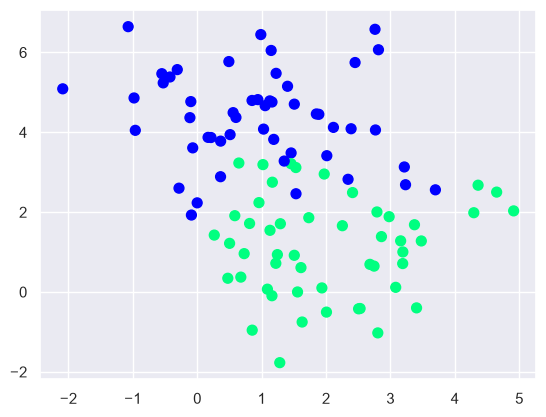

In [16]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

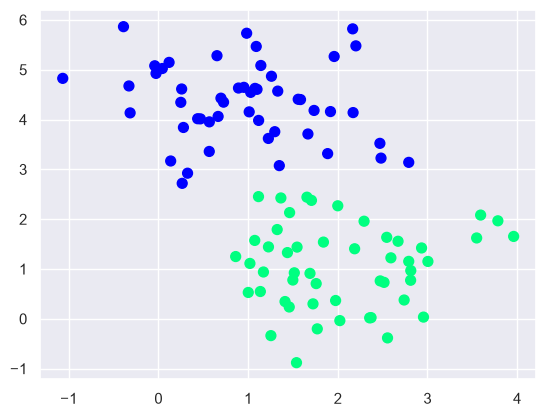

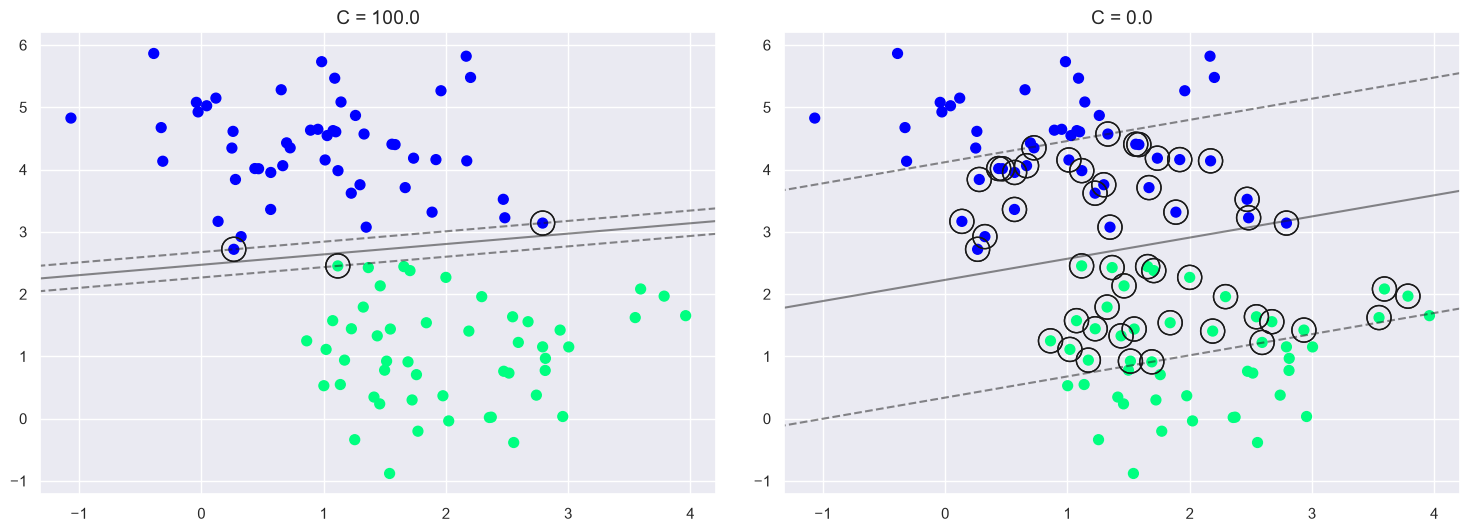

In [19]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

fig, ax = plt.subplots(1,2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

# for axi, C in zip(ax, [10.0, 0.1]):
for axi, C in zip(ax, [100.0, 0.01]): # --> this value can be change accounding margin distribution
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidths=1,
            facecolors='none',
            edgecolors='k'
        )
    axi.set_title('C = {0:.1f}'.format(C), size=14)

Class +        

  (+)   (+)   (+)

----------------  Decision boundary

  (-)   (-)   (-)

Class -

# Hard Margin SVM
In Support Vector Machine (SVM), a hard margin is used when the training data is perfectly linearly separable. The goal is to find the hyperplane that separates the classes with the maximum possible margin while making no classification errors. <br>
 <br>
    ​Margin  = 2/||w|| <br>
    This gives the distance between the two supporting hyperplanes: <br>
                w^T x + b = 1 <br>
            and <br>
                w^T x + b = -1 <br>
<br>
    Subject to -- > yi​(w^T xi ​+ b) ≥1,∀i<br>
<br>
where:<br>
- w = weight vector (defines the orientation of the hyperplane)
- b = bias (defines the position of the hyperplane)
- xi = training sample
- yi ∈{−1,+1} = class label
 <br>
Since the margin is 2/||w||, maximizing the margin means making ∥w∥ as small as possible. <br>
 <br>
- Why is it 2/∣∣w∣∣? <br>
--> The decision boundary is w^T x+b = 0 <br>
SVM creates two parallel lines: <br>
Positive side  -> w^T x + b = 1 <br>
Negative side  -> w^T x + b = -1 <br>
 <br>
The distance between these two lines is  2/||w|| <br>
 <br>
- What does ∣∣w∣∣ mean? <br>
--> Suppose   w=[3,4]  <br>
Then --->  ∣∣w∣∣= root(3^2 + 4^2) = root(25) = 5 <br>
 <br>
So margin becomes = 2/5 = 0.4 <br>
 <br>
--> Now suppose  w=[1,1] <br>
 <br>
Then ---> ∣∣w∣∣= root(2) <br>
 <br>
Margin becomes 2/root(2) = 1.41 <br>
 <br>
Now you notice that the smaller ||w|| gives larger margin and larger ||w|| gives smaller margin <br>
- Large margin = better separation.
- To maximize the margin, minimize ∣∣w∣∣.

# Soft Margin SVM

 Problem with Hard Margin SVM

--> Hard Margin SVM assumes that data can be separated perfectly.

But real dataset often look like this: 
Class +        

  (+)   (+)    (-)

----------------  Decision boundary

  (-)   (-)    (+)

Class -

Some points are mixed. A perfect separating line is impossible.

If we force a hard margin, SVM may fail.
<hr>

- Idea of Soft Margin SVM

-- Soft Margin SVM says:

"Allow some mistakes, but still try to keep the margin as large as possible."

It introduces a new variable called the slack variable:

ξi   -----> (Pronounced "xi")

The slack variable measures how much a point violates the margin.

Soft Margin Formula

The optimization formula is:

min/w,b,ξ 1/2 ∣∣w∣∣^2 + C ∑ ξi

Subject to:---- yi (w^T.xi + b) ≥ 1 − ξi

and  

ξi ≥ 0

Error penalty -- C∑ξi
	​
This punishes points that break the margin.

More violation:

ξi↑

More penalty.

- C = how strict the traffic police is
- ξi(xi) is called the slack variable.

Simple interpretation: ξi=amount by which a data point breaks the margin rule
	​
+ ξi=0 → no violation
+ Small ξi → small margin violation
+ Large ξi → misclassification